In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

In [2]:
print(housing.head(),housing.info(),housing.describe(),housing.ocean_proximity.value_counts(),sep='\n\n')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85    

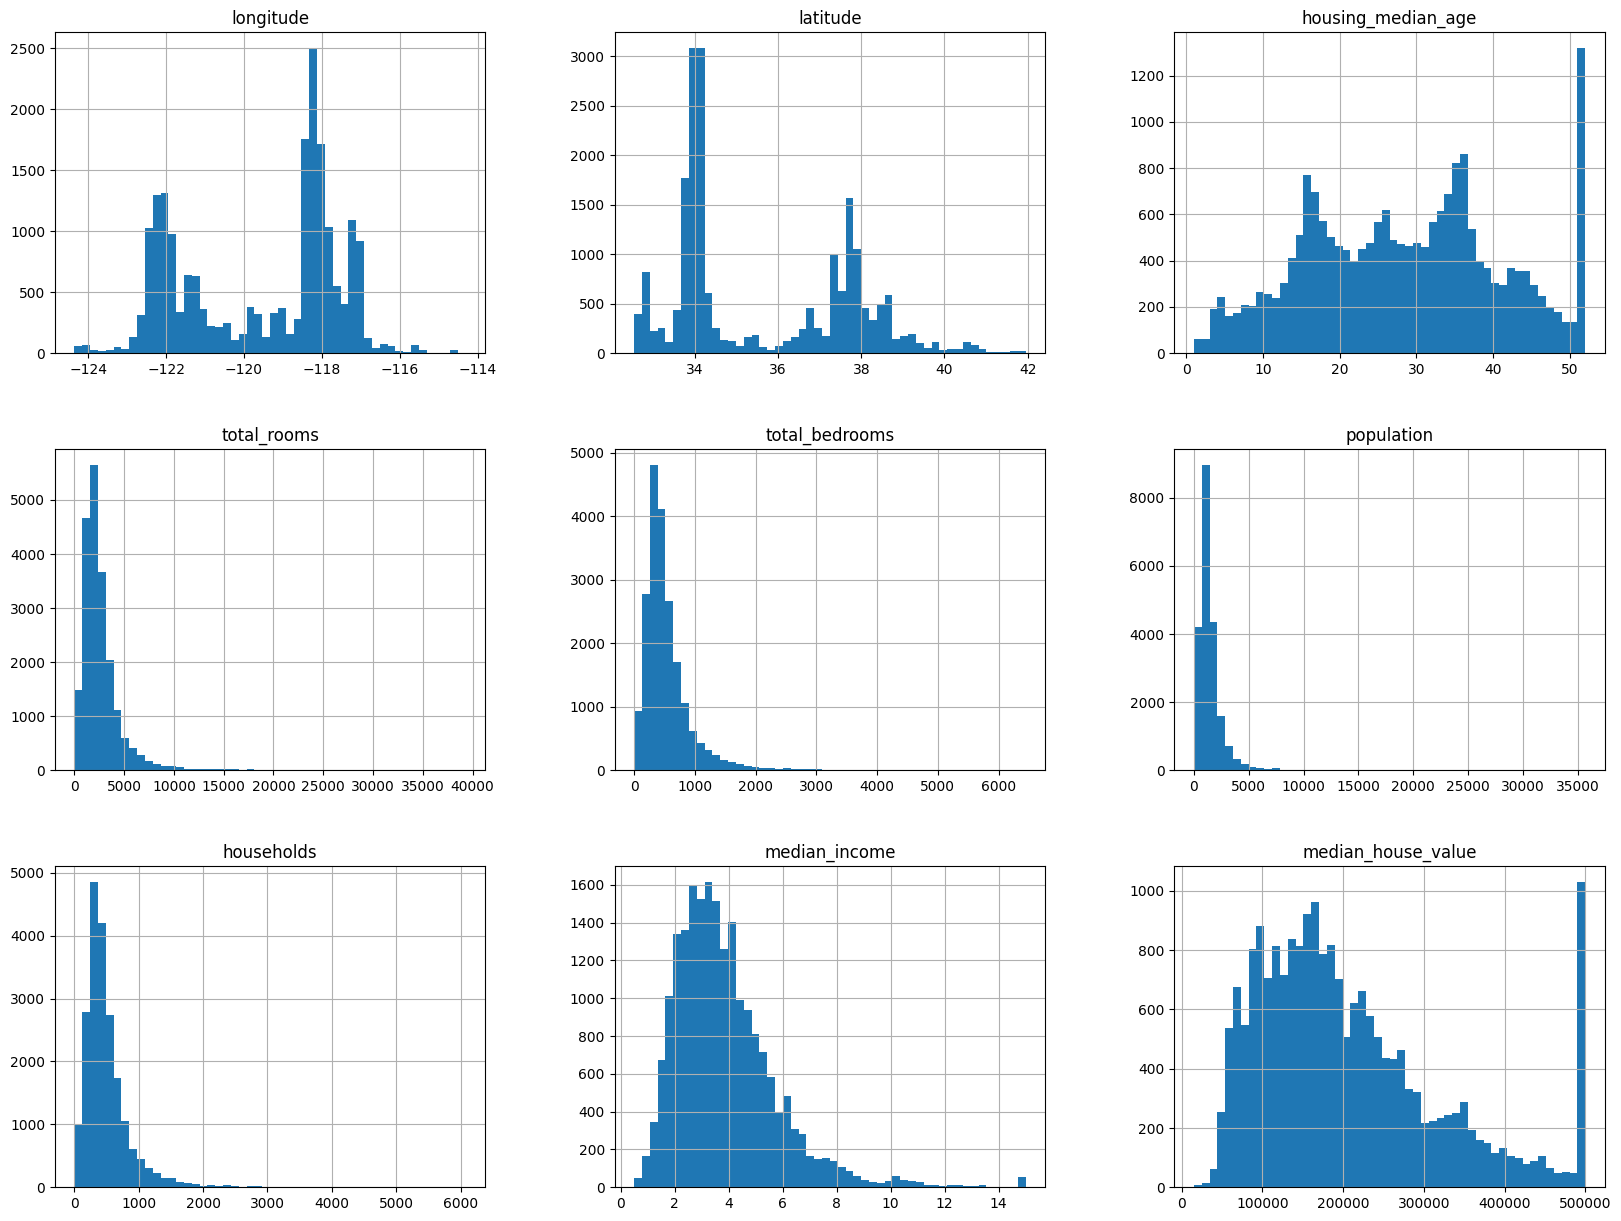

In [3]:
housing.hist(bins=50, figsize=(20, 15))
plt.show()

### ! note many histograms are skewed right. problem difficulty in identifying pattens 
### ! note housing_median_age there a peak at the end on 50 poor data collection

In [4]:
np.random.seed(42)

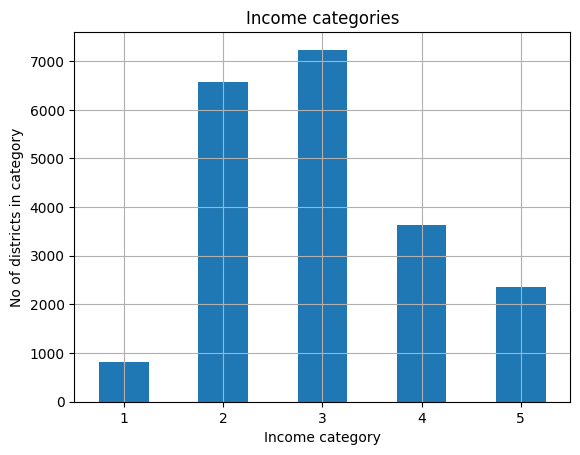

In [5]:
# stratified sampling
from sklearn.model_selection import StratifiedShuffleSplit
import matplotlib.pyplot as plt

df = housing.copy()
df["income_cat"] = pd.cut(df["median_income"],
                          bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                          labels=[1, 2, 3, 4, 5])

df["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("No of districts in category")
plt.title("Income categories")
plt.show()

split = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
for train_index, test_index in split.split(df, df["income_cat"]):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]

for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

C:\Users\jeron\AppData\Local\Temp\ipykernel_8568\1155724976.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


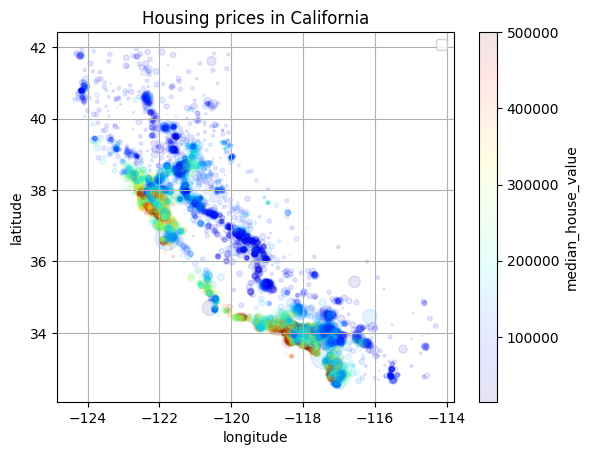

In [6]:
# Visualizing the data
housing = strat_train_set.copy()
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
             alpha=0.1, s=housing["population"]/100, c="median_house_value", cmap="jet", colorbar=True) # s is size of the point, c is color, cmap is colormap
plt.title("Housing prices in California")
plt.legend()
plt.show()

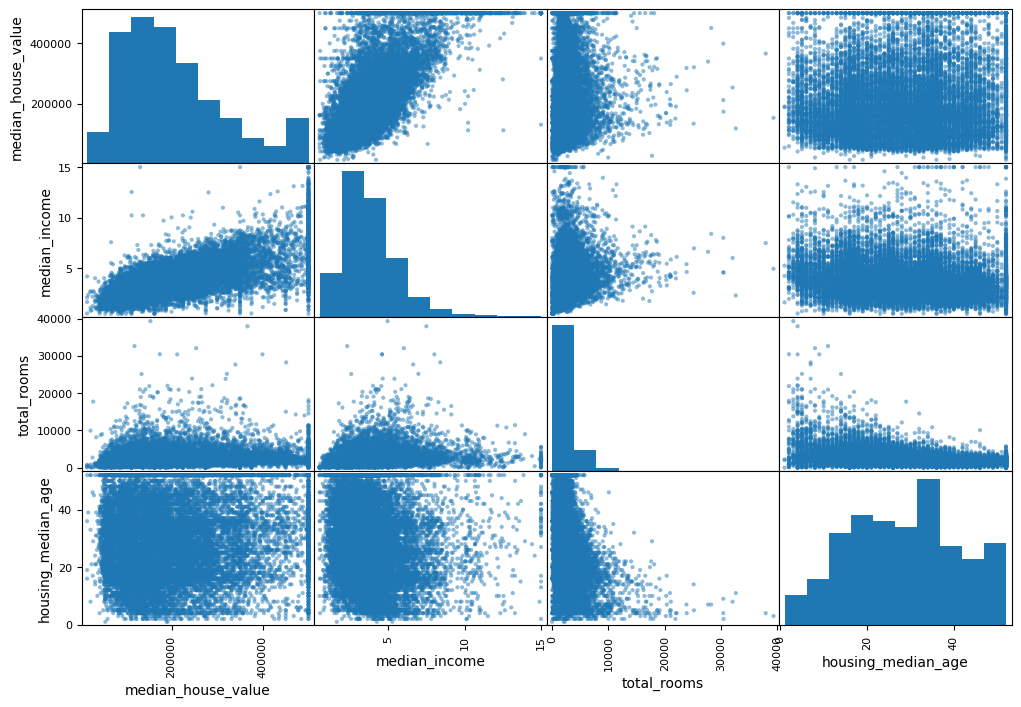

In [7]:
# correlation matrix
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms",
             "housing_median_age"]

scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()

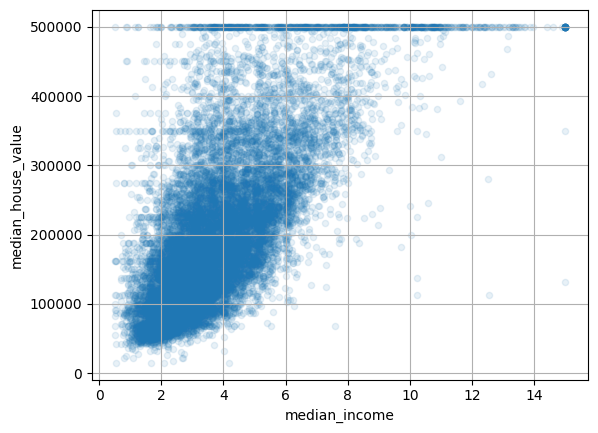

In [8]:
# correlation 
housing.plot(kind='scatter', x='median_income', y='median_house_value', alpha=0.1, grid=True)
plt.show()

!. we can see a upward trend and a data quirk at top (which is dangerous)

In [9]:
num_attributes = list(housing.columns)
cat_attributes = num_attributes.pop(num_attributes.index("ocean_proximity"))
cat_attributes , num_attributes

('ocean_proximity',
 ['longitude',
  'latitude',
  'housing_median_age',
  'total_rooms',
  'total_bedrooms',
  'population',
  'households',
  'median_income',
  'median_house_value'])

In [10]:
from sklearn.compose import make_column_selector
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_transformer
import numpy as np

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)
num_pipeline = make_pipeline(
    SimpleImputer(strategy="mean"),
    StandardScaler()
)

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object))
)

In [11]:
housing_p = preprocessing.fit_transform(housing)


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score

reg_lin = make_pipeline(
    preprocessing,
    LinearRegression()
)
reg_tree = make_pipeline(
    preprocessing,
    DecisionTreeRegressor()
)
reg_lin.fit(housing, housing["median_house_value"])
reg_tree.fit(housing, housing["median_house_value"])

lin_rmse = -cross_val_score(reg_lin, housing, housing["median_house_value"],
                           scoring="neg_mean_squared_error",cv=10)
tree_rmse = -cross_val_score(reg_tree, housing, housing["median_house_value"],
                           scoring="neg_mean_squared_error",cv=10)

print(pd.Series(lin_rmse).describe(), pd.Series(tree_rmse).describe(), sep="\n")

count    1.000000e+01
mean     3.447238e-19
std      1.598321e-19
min      2.568418e-20
25%      3.246811e-19
50%      3.751325e-19
75%      3.908043e-19
max      6.513668e-19
dtype: float64
count       10.000000
mean     11326.709506
std       3228.495141
min       6468.806784
25%       9192.913386
50%      10935.796487
75%      12944.821752
max      17652.938219
dtype: float64


! as you see linear regression performs better as dataset is linear

In [15]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state
    
    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self
    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)
    
    def get_feature_names_out(self, input_features=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

In [18]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import make_pipeline
import numpy as np
from sklearn.compose import ColumnTransformer
def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
       FunctionTransformer(lambda X: X[:,[0]] / X[:,[1]],feature_names_out=lambda f_transformer, feature_names_in: ["ratio"]),
       StandardScaler() 
    )

log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler()
)
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
def_num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)
preprocessing = ColumnTransformer([
    ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
    ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
    ("people_per_house", ratio_pipeline(), ["population", "households"]),
    ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population", "households", "median_income"]),
    ("geo", cluster_simil, ["latitude", "longitude"]),
    ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
], remainder=def_num_pipeline)


In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score

reg_lin = make_pipeline(
    preprocessing,
    LinearRegression()
)
reg_tree = make_pipeline(
    preprocessing,
    DecisionTreeRegressor()
)
reg_lin.fit(housing, housing["median_house_value"])
reg_tree.fit(housing, housing["median_house_value"])

lin_rmse = -cross_val_score(reg_lin, housing, housing["median_house_value"],
                           scoring="neg_mean_squared_error",cv=10)
tree_rmse = -cross_val_score(reg_tree, housing, housing["median_house_value"],
                           scoring="neg_mean_squared_error",cv=10)

print(pd.Series(lin_rmse).describe(), pd.Series(tree_rmse).describe(), sep="\n")

count    1.000000e+01
mean     2.788605e-20
std      1.615484e-20
min      9.852654e-21
25%      1.671861e-20
50%      2.297679e-20
75%      3.660099e-20
max      6.052079e-20
dtype: float64
count       10.000000
mean     14566.991218
std       5559.886274
min       6438.522108
25%      10431.556632
50%      13697.758934
75%      19891.732435
max      21892.792853
dtype: float64
